<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/hndling_missing_values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [66]:
df=pd.read_csv("data_science_job.csv")
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,NaN,NaN,42.0,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,52.0,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,50-99,Pvt Ltd,44.0,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,0.0,500-999,Pvt Ltd,97.0,0.0


In [67]:
df.isnull().mean()*100


,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [68]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [69]:
df[cols].head()

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
3,0.789,NaN,Graduate,0.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0


In [70]:
df['enrolled_university'].value_counts()

,count
enrolled_university,
no_enrollment,13817
Full time course,3757
Part time course,1198


In [71]:
len(df['enrolled_university'].dropna())/len(df)

0.9798517590562689

In [72]:
len(df['city_development_index'].dropna())/len(df)

0.97499739012423

In [73]:
new_df=df[cols].dropna()

In [74]:
new_df.shape,df.shape

((17182, 5), (19158, 13))

### Histograms of columns before and after dropping NaN values

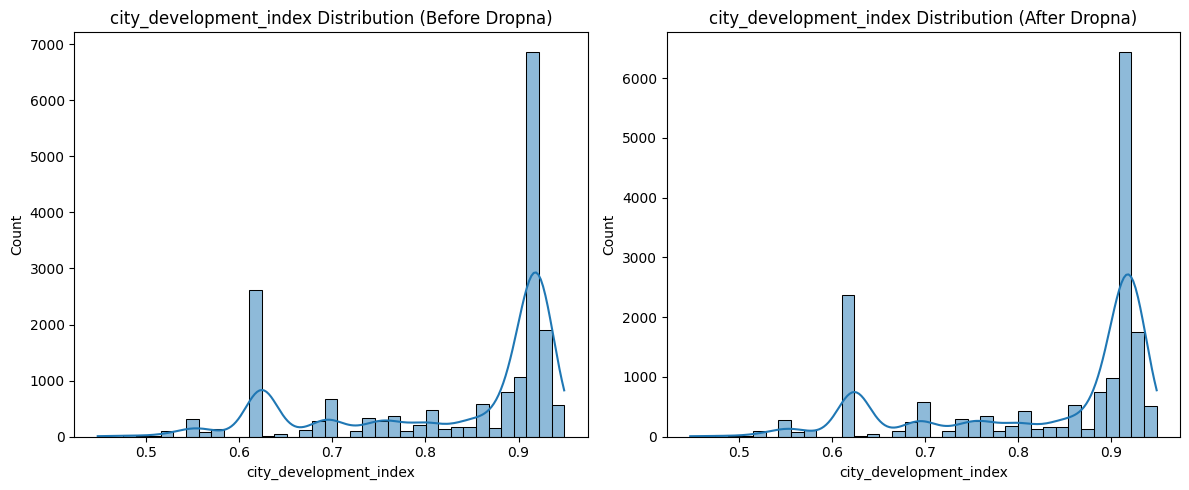

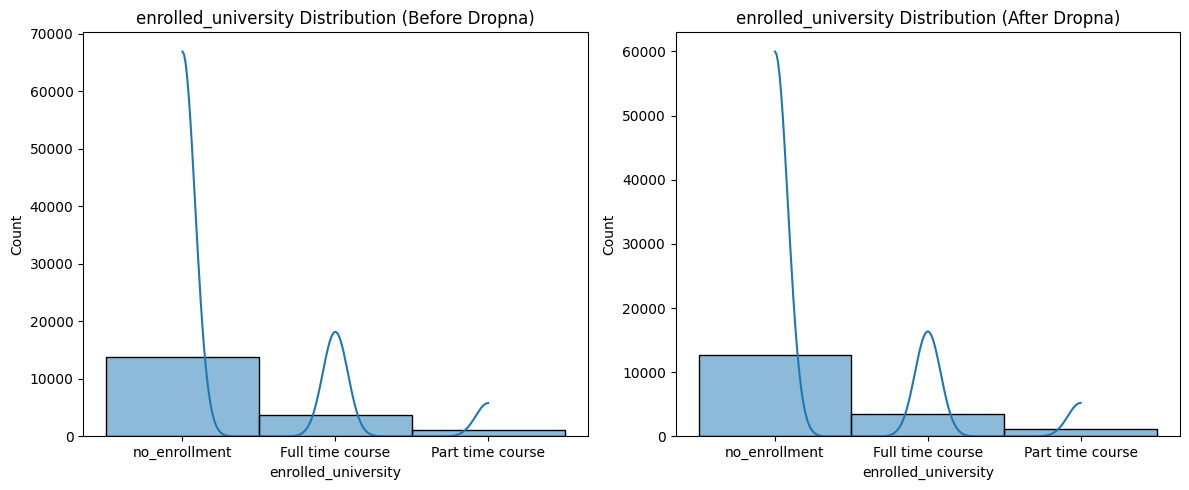

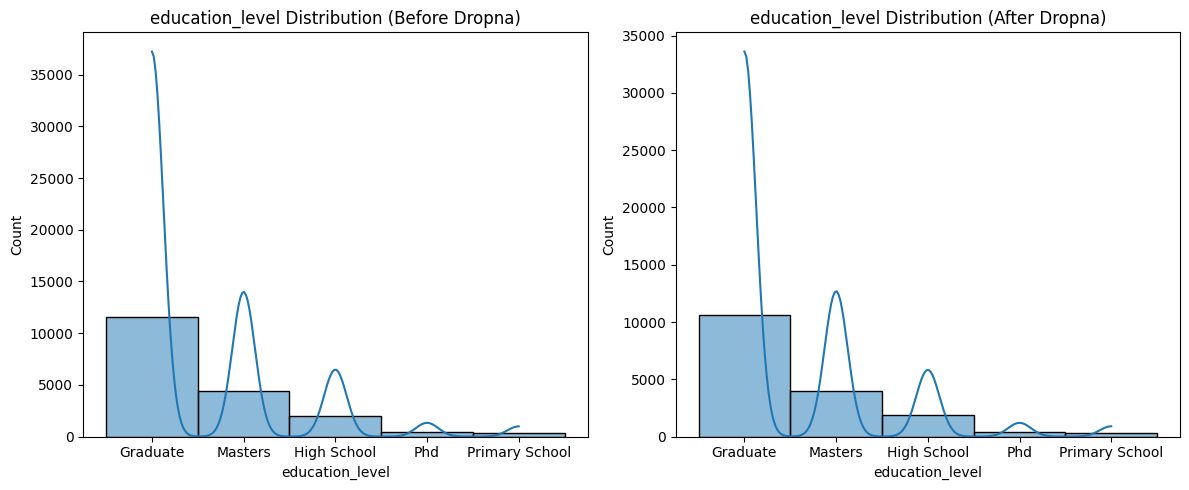

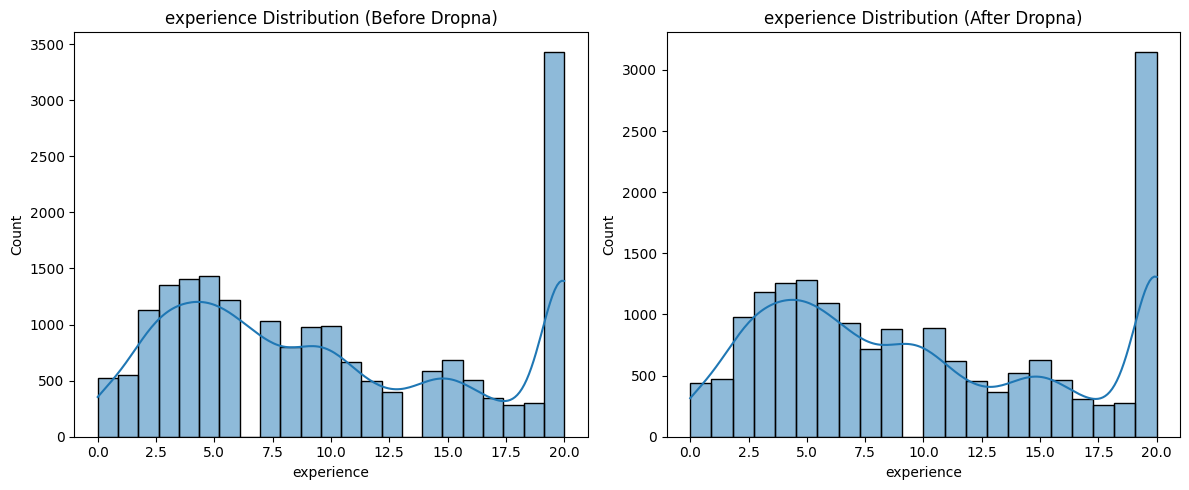

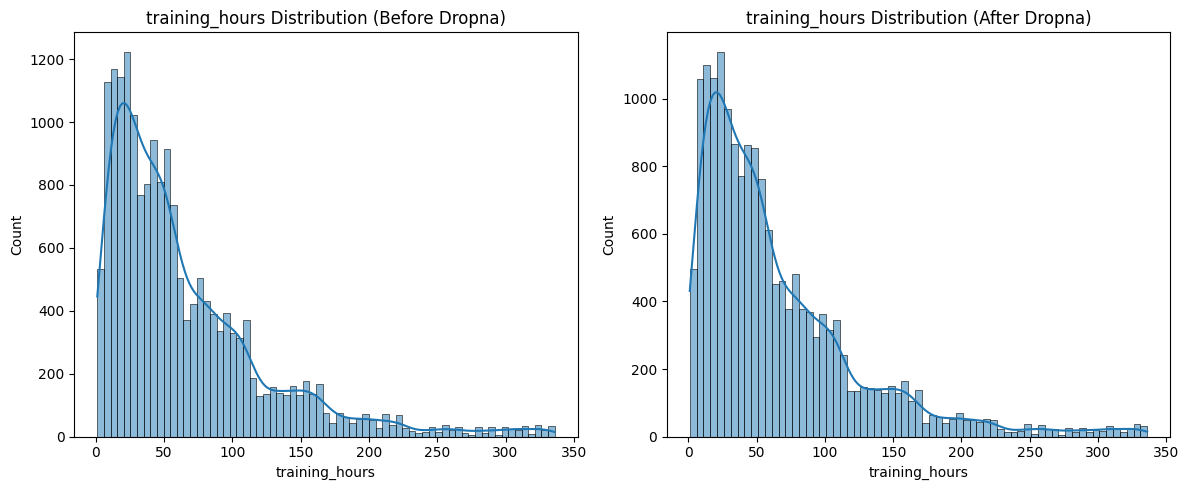

In [75]:
for col in cols:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'{col} Distribution (Before Dropna)')

    plt.subplot(1, 2, 2)
    sns.histplot(new_df[col], kde=True)
    plt.title(f'{col} Distribution (After Dropna)')

    plt.tight_layout()
    plt.show()

### Apply the imputation techniques


In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [77]:
df=pd.read_csv("/content/titanic_toy (1).csv")

In [78]:
df.sample(5)

,Age,Fare,Family,Survived
507,NaN,26.5500,0,1
538,NaN,14.5000,0,0
218,32.0,76.2917,0,1
392,28.0,7.9250,2,0
640,20.0,7.8542,0,0


In [79]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)

In [80]:
ct=ColumnTransformer(transformers=[
    ('si_mean',SimpleImputer(strategy='mean'),['Age']),
    ('si_median',SimpleImputer(strategy='median'),['Fare'])

],remainder='passthrough')

In [81]:
ct.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('si_mean', SimpleImputer(), ['Age']),
                                ('si_median', SimpleImputer(strategy='median'),
                                 ['Fare'])])

Accuracies:
                           Scenario  Accuracy
0                  After Imputation  0.653631
1  Before Imputation (Dropped NaNs)  0.679104
2               Original (Baseline)  0.770000


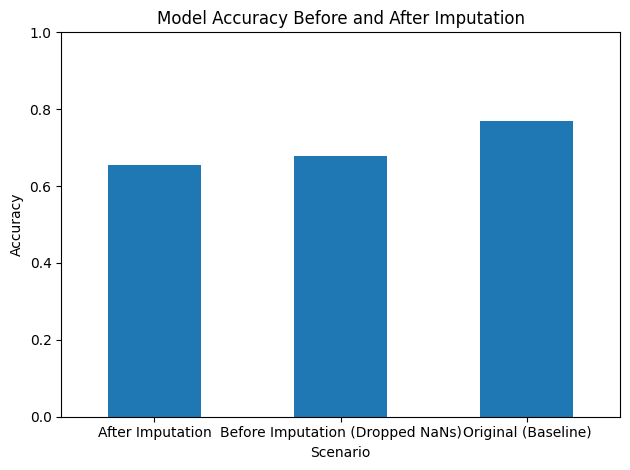

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Get the feature names after transformation
transformed_feature_names = ct.get_feature_names_out()

# 1. After Imputation: Transform data and train a model
x_train_transformed = ct.transform(x_train)
x_test_transformed = ct.transform(x_test)

# Convert to DataFrame to maintain column names and indices
x_train_transformed_df = pd.DataFrame(x_train_transformed, columns=transformed_feature_names, index=x_train.index)
x_test_transformed_df = pd.DataFrame(x_test_transformed, columns=transformed_feature_names, index=x_test.index)

# Clean up column names from the transformer prefixes
x_train_transformed_df.columns = [col.split('__')[-1] for col in x_train_transformed_df.columns]
x_test_transformed_df.columns = [col.split('__')[-1] for col in x_test_transformed_df.columns]

lr_imputed = LogisticRegression(solver='liblinear', random_state=42) # Using liblinear for small datasets
lr_imputed.fit(x_train_transformed_df, y_train)
y_pred_imputed = lr_imputed.predict(x_test_transformed_df)
accuracy_imputed = accuracy_score(y_test, y_pred_imputed)

# 2. Before Imputation: Drop rows with NaNs and train a model
x_train_dropped = x_train.dropna()
y_train_dropped = y_train.loc[x_train_dropped.index] # Align y with dropped x

x_test_dropped = x_test.dropna()
y_test_dropped = y_test.loc[x_test_dropped.index] # Align y with dropped x

lr_dropped = LogisticRegression(solver='liblinear', random_state=42)
lr_dropped.fit(x_train_dropped, y_train_dropped)
y_pred_dropped = lr_dropped.predict(x_test_dropped)
accuracy_dropped = accuracy_score(y_test_dropped, y_pred_dropped)

# 3. Visualize the accuracies using a pandas bar graph
accuracies = pd.DataFrame({
    'Scenario': ['After Imputation', 'Before Imputation (Dropped NaNs)', 'Original (Baseline)'],
    'Accuracy': [accuracy_imputed, accuracy_dropped, 0.77] # Replace 0.77 with actual baseline if available
})

print("Accuracies:")
print(accuracies)

accuracies.plot(x='Scenario', y='Accuracy', kind='bar', legend=False, title='Model Accuracy Before and After Imputation')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy
plt.xticks(rotation=0)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

###### Remaining Random ,Missing
Indicator,AtuoMissing

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from feature_engine.imputation import RandomSampleImputer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import OneHotEncoder

ModuleNotFoundError: No module named 'feature_engine'

In [85]:
def recognize_imputation_strategy(df, col, target):
    # 1. Check for Skewness
    skew = df[col].skew()
    skew_strategy = 'median' if abs(skew) > 0.5 else 'mean'

    # 2. Check for Target Shift (Randomness)
    nan_mean = df[df[col].isnull()][target].mean()
    obs_mean = df[df[col].notnull()][target].mean()
    # Handle cases where obs_mean might be 0 to avoid division by zero
    if obs_mean == 0:
        target_delta_strategy = 'indicator'  # If no observed values, indicator is a safe bet
    else:
        delta = abs(nan_mean - obs_mean) / obs_mean
        target_delta_strategy = 'indicator' if delta > 0.05 else 'simple'

    # Combine strategies (e.g., if target delta suggests indicator, use it, otherwise use skewness-based)
    final_strategy = {'imputer': skew_strategy, 'indicator': target_delta_strategy == 'indicator'}

    print(f"--- Analysis for {col} ---")
    print(f"Skewness: {skew:.2f} -> Imputer Strategy: {skew_strategy.capitalize()}")
    print(f"Target Delta: {delta:.2%} -> Indicator Strategy: {target_delta_strategy.capitalize()}")
    print(f"Recommended Strategy: Imputer: {final_strategy['imputer'].capitalize()}, Add Indicator: {final_strategy['indicator']}")
    print("---")
    return final_strategy

In [86]:
import pandas as pd
import numpy as np
df=pd.read_csv('AmesHousing.csv')

In [87]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Remove 'SalePrice' from numerical_cols as it is the target variable
if 'SalePrice' in numerical_cols:
    numerical_cols.remove('SalePrice')


In [88]:
df=pd.read_csv('AmesHousing.csv')
df.sample(3)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1847,1848,533223050,160,FV,NaN,5105,Pave,NaN,IR2,Lvl,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,148800
425,426,528108010,20,RL,110.0,14230,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,256300
1747,1748,528235000,80,RL,87.0,11084,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2007,WD,Family,175000


In [89]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Remove 'SalePrice' from numerical_cols as it is the target variable
if 'SalePrice' in numerical_cols:
    numerical_cols.remove('SalePrice')

print("Numerical Columns:")
print(numerical_cols)
print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold']

Categorical Columns:
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heatin

In [90]:
df[numerical_cols].isnull().sum()
df[categorical_cols].isnull().sum()

,0
MS Zoning,0
Street,0
Alley,2732
Lot Shape,0
Land Contour,0
Utilities,0
Lot Config,0
Land Slope,0
Neighborhood,0
Condition 1,0


In [ ]:
df[numerical_cols].dropna().shape,df[categorical_cols].dropna().shape

In [ ]:
numerical_imp=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean'))
])

In [ ]:
categorical_imp=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
print('Numerical columns used in ColumnTransformer:', numerical_cols)
print('Categorical columns used in ColumnTransformer:', categorical_cols)
ct=ColumnTransformer(transformers=[
    ('numerical_imp',numerical_imp,numerical_cols),
    ('categorical_imp',categorical_imp,categorical_cols)
],remainder='passthrough')

In [ ]:
pipe=Pipeline(steps=[
    ('ct',ct),
    ('model',Ridge())
])

In [ ]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', verbose=1, n_jobs=-1)
grid_search
# Fit GridSearchCV
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best R2 score: {grid_search.best_score_}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# For regression tasks, accuracy_score is not appropriate. Let's use r2_score.
from sklearn.metrics import r2_score

test_r2 = r2_score(y_test, y_pred)
print(f"Test R2 score with best model: {test_r2}")

In [ ]:
grid_search.best_params_
grid_search.best_score_
grid_search.best_estimator_

### Imputation Strategy Recognition for Numerical Columns with Missing Values

In [ ]:
# Identify numerical columns with missing values
missing_numerical_cols = df[numerical_cols].isnull().sum()
missing_numerical_cols = missing_numerical_cols[missing_numerical_cols > 0].index.tolist()

# Apply the imputation strategy recognition function
for col in missing_numerical_cols:
    recognize_imputation_strategy(df, col, 'SalePrice')

# bivaraint missing data handling

In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [92]:
df=pd.read_csv('/content/train (3).csv')[['Age','Pclass','Fare','Survived']]
df.sample(2)

,Age,Pclass,Fare,Survived
188,40.0,3,15.500,0
700,18.0,1,227.525,1


In [93]:
df.isnull().sum()

,0
Age,177
Pclass,0
Fare,0
Survived,0


In [125]:
x_test,x_train,y_test,y_train=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=2)



In [140]:
km=KNNImputer(n_neighbors=3,weights='distance')
x_train_trf=km.fit_transform(x_train)
x_test_trf=km.transform(x_test)

In [141]:
lr=LogisticRegression()
lr.fit(x_train_trf,y_train)

LogisticRegression()

In [142]:
pred=lr.predict(x_test_trf)

In [147]:
accuracy_score(y_test,pred)


0.6825842696629213

In [144]:
sm=SimpleImputer()
x_train_trf2=sm.fit_transform(x_train)
x_test_trf2=sm.transform(x_test)

In [145]:
ls=LogisticRegression()

In [146]:
ls.fit(x_train_trf2,y_train)
pred2=ls.predict(x_test_trf2)
accuracy_score(y_test,pred2)

0.6741573033707865

# Iternative imputation also named as  " Multivariate Imputation by Chained Equations"

In [198]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score


In [199]:
df=pd.read_csv('50_Startups.csv')[['R&D Spend','Administration','Marketing Spend','Profit']]

In [200]:
df.sample(2)

,R&D Spend,Administration,Marketing Spend,Profit
24,77044.01,99281.34,140574.81,108552.04
0,165349.20,136897.80,471784.10,192261.83


In [201]:
df.isnull().sum()

,0
R&D Spend,0
Administration,0
Marketing Spend,0
Profit,0


In [202]:
columns_to_inject_nans = ['R&D Spend', 'Administration', 'Marketing Spend']
missing_percent = 10

df = inject_nans(df, columns_to_inject_nans, missing_percent)

print("Missing values after injecting NaNs:")
display(df.isnull().sum())

Missing values after injecting NaNs:


,0
R&D Spend,5
Administration,5
Marketing Spend,5
Profit,0


In [203]:
df

,R&D Spend,Administration,Marketing Spend,Profit
0,NaN,136897.80,471784.10,192261.83
1,162597.70,151377.59,443898.53,191792.06
2,NaN,101145.55,NaN,191050.39
3,144372.41,118671.85,383199.62,182901.99
4,142107.34,91391.77,366168.42,166187.94
5,131876.90,NaN,362861.36,156991.12
6,134615.46,147198.87,127716.82,156122.51
7,130298.13,NaN,323876.68,155752.60
8,120542.52,148718.95,311613.29,152211.77
9,123334.88,108679.17,304981.62,149759.96


In [204]:
df.isnull().sum()

,0
R&D Spend,5
Administration,5
Marketing Spend,5
Profit,0


In [205]:
X = df.drop(columns=['Profit'])
y = df['Profit']
x_train,x_test,y_train,y_test=train_test_split(X, y, test_size=0.2,random_state=2)

In [206]:
num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = x_train.select_dtypes(include=['object']).columns

In [207]:
num_transformer=Pipeline(steps=[
    ('iterative_imputer',IterativeImputer(random_state=42,max_iter=10))
])

In [208]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [209]:
tran=ColumnTransformer(transformers=[
    ('num',num_transformer,num_cols),
    ('cat',cat_transformer,cat_cols)

]
)

In [211]:
pipe=Pipeline(steps=[
    ('tran',tran),
    ('model',Ridge())
])

In [212]:
pipe.fit(x_train,y_train)

Pipeline(steps=[('tran',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('iterative_imputer',
                                                                   IterativeImputer(random_state=42))]),
                                                  Index(['R&D Spend', 'Administration', 'Marketing Spend'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index([], dtype='object'))])),
                ('model', Ridge())])

In [216]:
x=pipe.predict(x_test)
r2_score(y_test,x)

0.9652133757876573

In [197]:
from sklearn.metrics import r2_score
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge

# Redefine num_transformer with the correct random_state
num_transformer=Pipeline(steps=[
    ('iterative_imputer',IterativeImputer(random_state=42,max_iter=10))
])

# Redefine cat_transformer
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Redefine ColumnTransformer (tran)
tran=ColumnTransformer(transformers=[
    ('num',num_transformer,num_cols),
    ('cat',cat_transformer,cat_cols)
])

# Redefine model
model = Ridge(random_state=42)

# Create the full pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', tran),
    ('regressor', model)
])

# Fit the pipeline
pipeline.fit(x_train, y_train)

# Make predictions
y_pred = pipeline.predict(x_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2:.4f}")

R2 Score: 0.9093
